In [ ]:
!pip install torch scikit-learn pandas numpy pyarrow

In [1]:
from google.colab import drive
import os, shutil

drive.mount('/content/drive')

Mounted at /content/drive


Using device: cuda
Loading data...
Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']
Train: 1152 Test: 288
Epoch 10/70 | Train Loss: 1.6394 Acc: 0.3759 F1m: 0.2956 | Test Loss: 1.7176 Acc: 0.3542 F1m: 0.2669
Epoch 20/70 | Train Loss: 1.3849 Acc: 0.5399 F1m: 0.4908 | Test Loss: 1.6629 Acc: 0.4375 F1m: 0.3980
Epoch 30/70 | Train Loss: 1.0265 Acc: 0.7248 F1m: 0.6967 | Test Loss: 1.4441 Acc: 0.5556 F1m: 0.5406
Epoch 40/70 | Train Loss: 0.7777 Acc: 0.8568 F1m: 0.8328 | Test Loss: 1.3641 Acc: 0.5903 F1m: 0.5818
Epoch 50/70 | Train Loss: 0.6592 Acc: 0.9167 F1m: 0.9028 | Test Loss: 1.3731 Acc: 0.6319 F1m: 0.6244
Epoch 60/70 | Train Loss: 0.6242 Acc: 0.9358 F1m: 0.9247 | Test Loss: 1.3826 Acc: 0.6354 F1m: 0.6287
Epoch 70/70 | Train Loss: 0.5946 Acc: 0.9497 F1m: 0.9418 | Test Loss: 1.3545 Acc: 0.6562 F1m: 0.6493

Final Test → Acc: 0.6562 | Weighted F1: 0.6620 | Macro F1: 0.6493


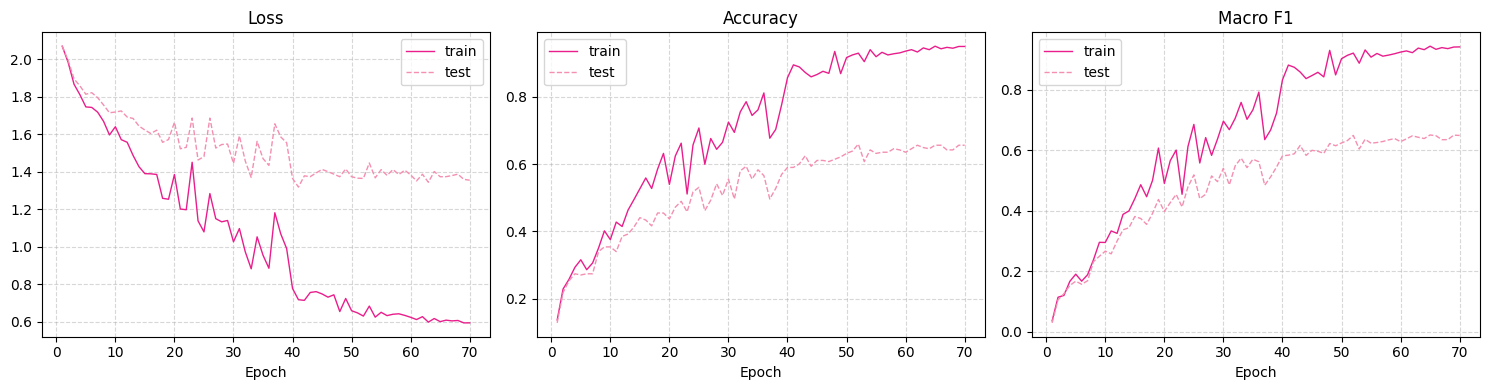

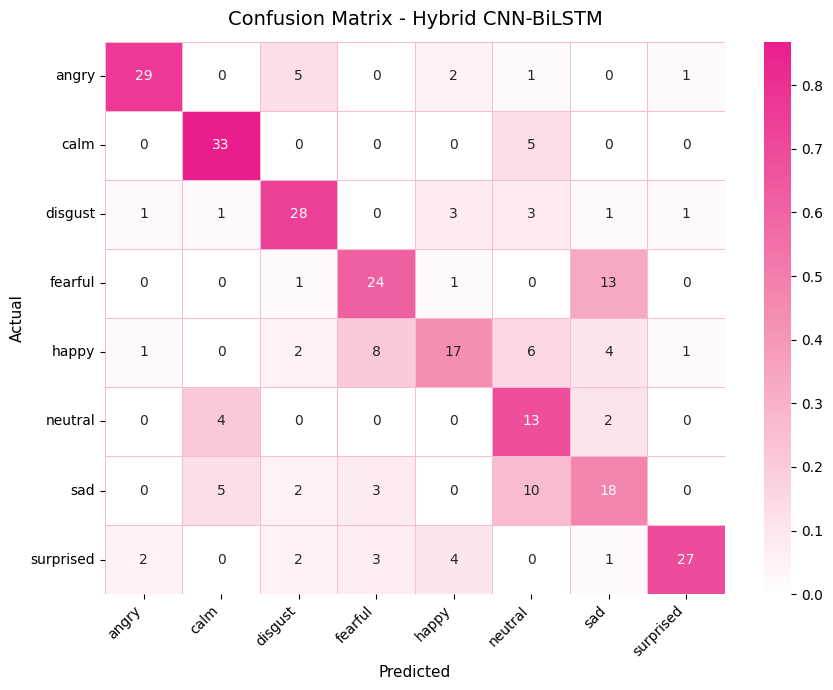

In [3]:
from __future__ import annotations

import random
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns

# =====================================================================
# CONFIG
# =====================================================================

TRAIN_PATH = "/content/drive/MyDrive/Colab Notebooks/train_features.parquet"
TEST_PATH  = "/content/drive/MyDrive/Colab Notebooks/test_features.parquet"

BATCH_SIZE = 64
EPOCHS = 70
LEARNING_RATE = 1e-3

# Heightened Regularization
DROPOUT = 0.4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTH = 0.1

# Architecture Configuration
CNN_CHANNELS = [64, 128, 128]
CNN_KERNEL = 3

LSTM_HIDDEN = 256
LSTM_LAYERS = 2
LSTM_BIDIRECTIONAL = True

FC_HIDDEN_DIM = 64

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

METADATA_COLS = [
    "file_path",
    "emotion_code",
    "emotion_label",
    "actor_id",
    "frame_index",
    "time_seconds",
]

SEED = 46

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# =====================================================================
# DATA
# =====================================================================

def get_feature_cols(df):
    return [c for c in df.columns if c not in METADATA_COLS]


def build_sequences(df, feature_cols, label_encoder):
    sequences = []
    labels_raw = []

    for filepath, group in df.groupby("file_path", sort=False):
        group = group.sort_values("frame_index")

        x = torch.tensor(group[feature_cols].values, dtype=torch.float32)
        sequences.append(x)

        labels_raw.append(str(group["emotion_label"].mode()[0]))

    labels = label_encoder.transform(labels_raw)
    return sequences, labels.tolist()


class UtteranceDataset(Dataset):
    def __init__(self, seqs, labels):
        self.seqs = seqs
        self.labels = labels

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        return self.seqs[idx], self.labels[idx]


def collate_fn(batch):
    seqs, labels = zip(*batch)
    lengths = torch.tensor([s.shape[0] for s in seqs], dtype=torch.long)
    padded = pad_sequence(seqs, batch_first=True)
    labels = torch.tensor(labels, dtype=torch.long)
    return padded, lengths, labels

# =====================================================================
# MODEL SUB-MODULES
# =====================================================================

class AttentionPooling(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_output, mask):
        attn_weights = self.attn(lstm_output)
        attn_weights = attn_weights.masked_fill(mask == 0, -1e9)
        attn_weights = torch.softmax(attn_weights, dim=1)
        pooled = torch.sum(lstm_output * attn_weights, dim=1)
        return pooled

# =====================================================================
# MAIN ARCHITECTURE
# =====================================================================

class AdvancedSERModel(nn.Module):
    def __init__(self, input_feature_dim, num_classes):
        super().__init__()

        cnn_layers = []
        in_ch = input_feature_dim

        for out_ch in CNN_CHANNELS:
            cnn_layers += [
                nn.Conv1d(in_ch, out_ch, kernel_size=CNN_KERNEL, padding=CNN_KERNEL//2, stride=2),
                nn.BatchNorm1d(out_ch),
                nn.ReLU(),
                nn.Dropout(DROPOUT)
            ]
            in_ch = out_ch
        self.cnn = nn.Sequential(*cnn_layers)

        self.lstm = nn.LSTM(
            input_size=CNN_CHANNELS[-1],
            hidden_size=LSTM_HIDDEN,
            num_layers=LSTM_LAYERS,
            batch_first=True,
            bidirectional=LSTM_BIDIRECTIONAL,
            dropout=DROPOUT if LSTM_LAYERS > 1 else 0
        )

        lstm_out_dim = LSTM_HIDDEN * 2 if LSTM_BIDIRECTIONAL else LSTM_HIDDEN

        self.attention_pool = AttentionPooling(lstm_out_dim)

        self.classifier = nn.Sequential(
            nn.Linear(lstm_out_dim, FC_HIDDEN_DIM),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(FC_HIDDEN_DIM, num_classes)
        )

    def forward(self, x, lengths):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)

        out, _ = self.lstm(x)

        T_new = out.shape[1]
        adjusted_lengths = torch.clamp((lengths / 2).long(), min=1, max=T_new)

        mask = (torch.arange(T_new, device=x.device)[None, :] < adjusted_lengths.to(x.device)[:, None])
        mask = mask.unsqueeze(-1)

        pooled = self.attention_pool(out, mask)
        return self.classifier(pooled)

# =====================================================================
# EVAL
# =====================================================================

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    preds, labels = [], []
    loss_sum = 0

    for x, lengths, y in loader:
        x, lengths, y = x.to(DEVICE), lengths.to(DEVICE), y.to(DEVICE)
        logits = model(x, lengths)

        loss_sum += criterion(logits, y).item() * len(y)
        preds.extend(logits.argmax(1).cpu().numpy())
        labels.extend(y.cpu().numpy())

    return (
        loss_sum / len(loader.dataset),
        accuracy_score(labels, preds),
        f1_score(labels, preds, average="weighted", zero_division=0),
        f1_score(labels, preds, average="macro", zero_division=0),
        preds,
        labels,
    )

# =====================================================================
# VISUALIZATION
# =====================================================================

def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    pink_train = "#e91e8c"
    pink_test  = "#f48fb1"

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    titles     = ["Loss", "Accuracy", "Macro F1"]
    train_keys = ["train_loss", "train_acc", "train_f1m"]
    test_keys  = ["test_loss",  "test_acc",  "test_f1m"]

    for ax, title, tr_key, te_key in zip(axes, titles, train_keys, test_keys):
        ax.plot(epochs, history[tr_key], label="train", color=pink_train, linewidth=1)
        ax.plot(epochs, history[te_key], label="test",  color=pink_test,  linewidth=1, linestyle="--")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend()

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(labels, preds, class_names):
    cm = confusion_matrix(labels, preds)
    cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    pink_cmap = mcolors.LinearSegmentedColormap.from_list(
        "pink_cmap", ["#ffffff", "#f48fb1", "#e91e8c"]
    )

    plt.figure(figsize=(9, 7))
    sns.heatmap(
        cm_normalized,
        annot=cm,
        fmt="d",
        cmap=pink_cmap,
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=0.5,
        linecolor="#f8bbd0",
    )
    plt.title("Confusion Matrix - Hybrid CNN-BiLSTM", fontsize=14, pad=12)
    plt.xlabel("Predicted", fontsize=11)
    plt.ylabel("Actual", fontsize=11)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# =====================================================================
# MAIN RUNNER
# =====================================================================

if __name__ == "__main__":
    print("Loading data...")
    train_df = pd.read_parquet(TRAIN_PATH)
    test_df = pd.read_parquet(TEST_PATH)

    feature_cols = get_feature_cols(train_df)

    le = LabelEncoder()
    train_labels_raw = (
        train_df.groupby("file_path")["emotion_label"]
        .apply(lambda x: str(x.mode()[0]))
        .tolist()
    )
    le.fit(train_labels_raw)

    train_seqs, train_labels = build_sequences(train_df, feature_cols, le)
    test_seqs, test_labels = build_sequences(test_df, feature_cols, le)

    num_classes = len(le.classes_)
    print("Classes:", le.classes_)
    print("Train:", len(train_seqs), "Test:", len(test_seqs))

    g = torch.Generator()
    g.manual_seed(SEED)

    train_loader = DataLoader(
        UtteranceDataset(train_seqs, train_labels),
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=collate_fn,
        generator=g,
    )
    test_loader = DataLoader(
        UtteranceDataset(test_seqs, test_labels),
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_fn,
    )

    model = AdvancedSERModel(len(feature_cols), num_classes).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    history = {
        "train_loss": [], "test_loss": [],
        "train_acc":  [], "test_acc":  [],
        "train_f1w":  [], "test_f1w":  [],
        "train_f1m":  [], "test_f1m":  [],
    }

    for epoch in range(EPOCHS):
        model.train()
        for x, lengths, y in train_loader:
            x, lengths, y = x.to(DEVICE), lengths.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x, lengths), y)
            loss.backward()
            optimizer.step()

        tr_loss, tr_acc, tr_f1w, tr_f1m, _, _ = evaluate(model, train_loader, criterion)
        te_loss, te_acc, te_f1w, te_f1m, test_preds, test_true = evaluate(model, test_loader, criterion)
        scheduler.step(te_loss)

        history["train_loss"].append(tr_loss)
        history["test_loss"].append(te_loss)
        history["train_acc"].append(tr_acc)
        history["test_acc"].append(te_acc)
        history["train_f1w"].append(tr_f1w)
        history["test_f1w"].append(te_f1w)
        history["train_f1m"].append(tr_f1m)
        history["test_f1m"].append(te_f1m)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS} | "
                  f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} F1m: {tr_f1m:.4f} | "
                  f"Test Loss: {te_loss:.4f} Acc: {te_acc:.4f} F1m: {te_f1m:.4f}")

    print(f"\nFinal Test → Acc: {te_acc:.4f} | Weighted F1: {te_f1w:.4f} | Macro F1: {te_f1m:.4f}")
    plot_history(history)
    plot_confusion_matrix(test_true, test_preds, class_names=le.classes_)